# SVD e PCA per l'Analisi di Difetti Industriali — MVTec AD 'Screw'

**Progetto — Statistical Methods — Confronto su un dataset differente**

Questo notebook applica la stessa pipeline sviluppata per le radiografie mediche
(SVD + PCA per compressione e classificazione) al dataset **MVTec AD 'Screw'**,
composto da immagini di viti industriali normali ('good') e difettose.

L'obiettivo di questa sezione non è trattare il problema nel senso classico di
**anomaly detection**, ma usare un dataset con anomalie industriali come banco di
prova per confrontare il comportamento di **SVD** e **PCA** in un dominio diverso
rispetto a quello medico. In questo modo possiamo verificare se le conclusioni
ottenute sul dataset precedente si confermano oppure no quando gli item sono meno
omogenei e la variabilità del dataset cambia natura.

### Differenze rispetto al dataset medico

| Aspetto | Medico | MVTec Screw |
|---|---|---|
| Tipo di immagine | Radiografie 2D | Fotografie ottiche RGB (convertite in scala di grigi) |
| Classi | 4 (COVID, Normal, Pneumonia, TB) | 2 (good, defective) |
| Classificazione | Multi-classe diagnostica | **Binaria** good vs difettoso |
| Dataset 'defective' | — | Aggregazione di 5 tipi di difetto<br>(manipulated_front, scratch_head, scratch_neck, thread_side, thread_top) |

### Impostazione del confronto

MVTec AD è spesso usato in letteratura come benchmark di **anomaly detection**.
Qui però scegliamo intenzionalmente una formulazione **binaria supervisionata**
(good vs defective) perché il focus del lavoro non è confrontare algoritmi di
anomaly detection, ma osservare come **SVD** e **PCA** si comportano quando la
stessa pipeline viene trasferita su un dataset differente, con oggetti simili ma
con presenza di anomalie locali.

Questa scelta rende il confronto coerente con il notebook medico: manteniamo la
stessa logica sperimentale e cambiamo il dominio dei dati, così possiamo capire
se i risultati precedenti sono robusti oppure dipendono fortemente dal tipo di
immagini analizzate.

Il codice riusa i moduli di `src/` (refactorati per accettare classi e directory dataset come parametri opzionali) e aggiunge `mvtec/mvtec_loader.py` per il caricamento specifico del dataset.


In [1]:
# === IMPORT DEI MODULI ===
import sys, os, importlib
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import matplotlib.pyplot as plt

import src.svd_engine as svd_engine
import src.visualization as visualization
import src.analysis as analysis
import src.pca_engine as pca_engine
import src.classification as classification
import mvtec.mvtec_loader as mvtec_loader

# In notebook Jupyter i moduli possono restare in cache tra una run e l'altra.
# Il reload evita errori dovuti a firme di funzione non aggiornate.
importlib.reload(svd_engine)
importlib.reload(visualization)
importlib.reload(analysis)
importlib.reload(pca_engine)
importlib.reload(classification)
importlib.reload(mvtec_loader)

from src.svd_engine import (apply_svd, reconstruct_svd, compression_ratio,
                            mse, psnr, cumulative_variance)
from src.visualization import (plot_exploration, plot_svd_reconstruction,
                               plot_class_comparison)
from src.analysis import plot_scree, plot_mse_psnr, print_summary_table
from src.pca_engine import run_pca, plot_pca_scatter, plot_eigenfaces
from src.classification import (prepare_feature_sets, run_classification,
                                plot_confusion_matrix, plot_roc_curves,
                                plot_classification_comparison,
                                plot_hero_tradeoff)

from mvtec.mvtec_loader import (
    count_mvtec_images, print_mvtec_counts,
    load_mvtec_dataset, load_mvtec_sample_images,
    MVTEC_CLASSES, MVTEC_CLASS_COLORS, MVTEC_SHORT_LABELS
)

MVTEC_DATASET_DIR = os.path.join(ROOT, 'data', 'mvtec', 'screw')
OUTPUT_DIR = os.path.join(ROOT, 'outputs_mvtec')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_SIZE = (256, 256)

print(f'Dataset: {MVTEC_DATASET_DIR}')
print(f'Output : {OUTPUT_DIR}')
print(f'Target size: {TARGET_SIZE}')
print(f'Classi: {MVTEC_CLASSES}')

Dataset: C:\Users\1\OneDrive - Politecnico di Bari\POLIBA\1 anno\1 semestre\statistical metods\progetto\Medical Image Compression and Analysis\data\mvtec\screw
Output : C:\Users\1\OneDrive - Politecnico di Bari\POLIBA\1 anno\1 semestre\statistical metods\progetto\Medical Image Compression and Analysis\outputs_mvtec
Target size: (256, 256)
Classi: ['good', 'defective']


---
## Fase 1 — Esplorazione del Dataset

Il dataset MVTec Screw contiene immagini 1024×1024 PNG di viti fotografate dall'alto. Verifichiamo prima i conteggi delle sotto-classi, poi mostriamo un campione per macro-classe con l'istogramma delle intensità dei pixel.


In [2]:
# === CONTEGGIO IMMAGINI ===
counts = count_mvtec_images(MVTEC_DATASET_DIR)
print_mvtec_counts(counts)

CONTEGGIO IMMAGINI — MVTec AD 'Screw'

--- Good (normali) ---
  train/good:  320
  test/good:    41
  TOTALE good:  361

--- Defective (tutti i difetti aggregati) ---
  test/manipulated_front     :   24
  test/scratch_head          :   24
  test/scratch_neck          :   25
  test/thread_side           :   23
  test/thread_top            :   23
  TOTALE defective:  119


In [3]:
# === CARICAMENTO CAMPIONI ===
sample_images = load_mvtec_sample_images(MVTEC_DATASET_DIR)

for cls, arr in sample_images.items():
    print(f'  {cls:<12s}: shape={arr.shape}, dtype={arr.dtype}, '
          f'min={arr.min()}, max={arr.max()}, mean={arr.mean():.1f}')

  good        : shape=(1024, 1024), dtype=uint8, min=30, max=210, mean=176.7
  defective   : shape=(1024, 1024), dtype=uint8, min=24, max=218, mean=181.5


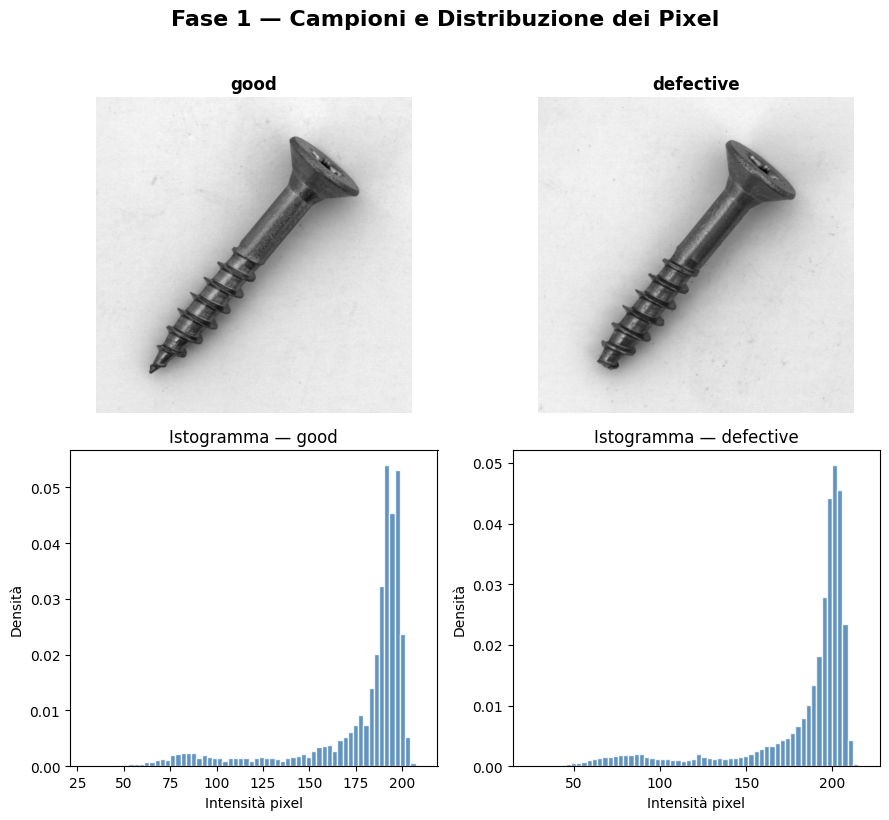

In [4]:
# === VISUALIZZAZIONE CAMPIONI + ISTOGRAMMA ===
plot_exploration(
    sample_images,
    classes=MVTEC_CLASSES,
    output_dir=OUTPUT_DIR,
)

---
## Fase 2 — Caricamento Bilanciato del Dataset

Caricamento del batch completo con:
- conversione in scala di grigi
- resize a 256×256 (coerente con il progetto medico)
- normalizzazione in [0, 1]
- **bilanciamento** delle classi: 'good' (361 disponibili) sotto-campionata a |'defective'| (119) per evitare squilibri che falserebbero accuracy e ROC. Seed fissato per riproducibilità.

**Attenzione**: a differenza del progetto medico qui NON applichiamo la correzione di tilt — le immagini MVTec sono acquisite con setup fisso e non hanno inclinazione meccanica.


In [5]:
# === CARICAMENTO BATCH BILANCIATO ===
images_by_class, all_images, labels = load_mvtec_dataset(
    MVTEC_DATASET_DIR,
    target_size=TARGET_SIZE,
    balance=True,
    random_state=42,
)

print()
print(f'all_images shape: {all_images.shape}')
print(f'labels shape:     {labels.shape}')
print(f'Classi presenti:  {np.unique(labels, return_counts=True)}')

  Trovate 361 immagini 'good'
  Trovate 119 immagini 'defective' (aggregazione di 5 tipi di difetto)
  [BALANCE] 'good' ridotto a 119 (seed=42)
  Caricate 119 immagini per 'good'
  Caricate 119 immagini per 'defective'

Dataset totale: (238, 256, 256)  -- 238 immagini, 256x256 pixel

all_images shape: (238, 256, 256)
labels shape:     (238,)
Classi presenti:  (array(['defective', 'good'], dtype='<U9'), array([119, 119]))


---
## Fase 3 — Decomposizione SVD

La Singular Value Decomposition $A = U \Sigma V^T$ permette di rappresentare un'immagine come somma pesata di rank-1 outer products. Troncando la somma ai primi $k$ valori singolari otteniamo la migliore approssimazione di rango $k$ in norma di Frobenius (teorema di Eckart–Young).


    k    Compressione         MSE   PSNR (dB)
------------------------------------------------
    1          0.78%    0.006099       22.15
    5          3.91%    0.000828       30.82
   10          7.83%    0.000278       35.57
   20         15.66%    0.000095       40.22
   50         39.14%    0.000023       46.33
  100         78.28%    0.000007       51.69
  200        100.00%    0.000000       66.74


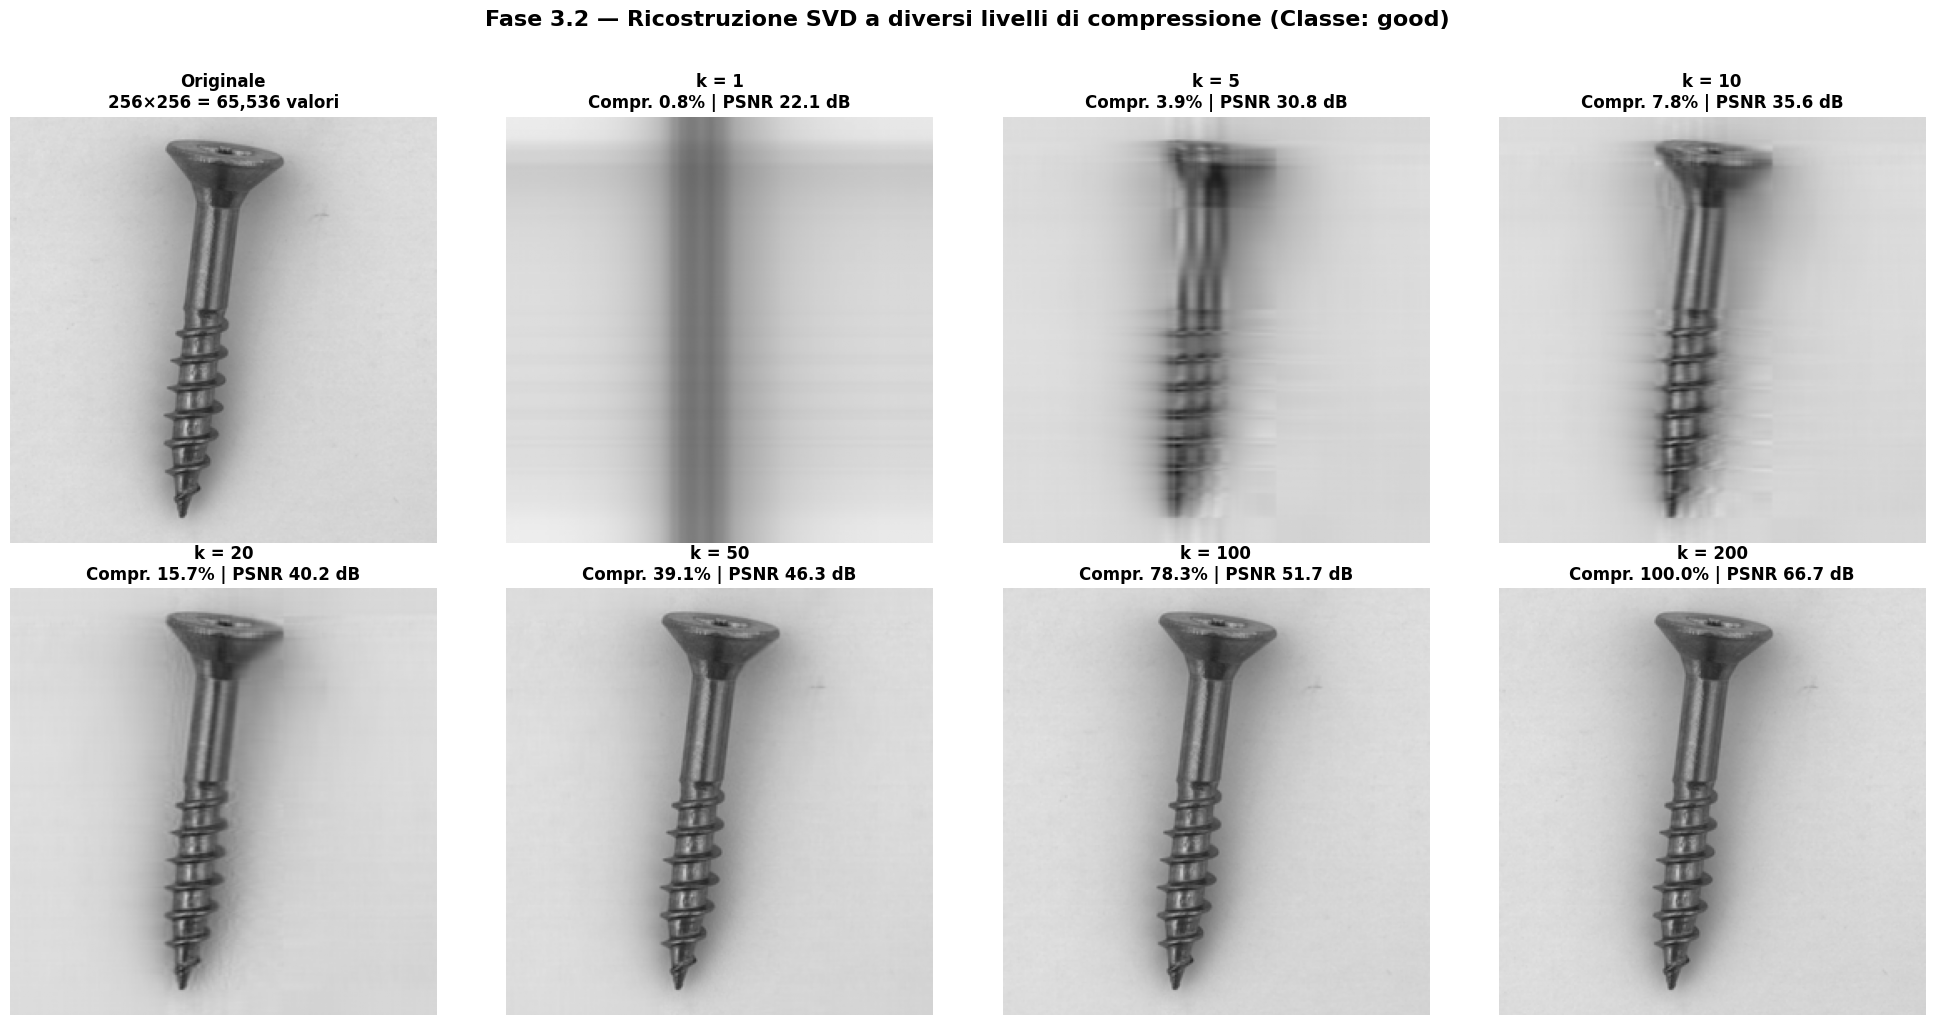

In [6]:
# === DEMO SVD: RICOSTRUZIONE A DIVERSI k ===
demo_img = images_by_class['good'][0]

plot_svd_reconstruction(
    demo_img,
    class_name='good',
    output_dir=OUTPUT_DIR,
)

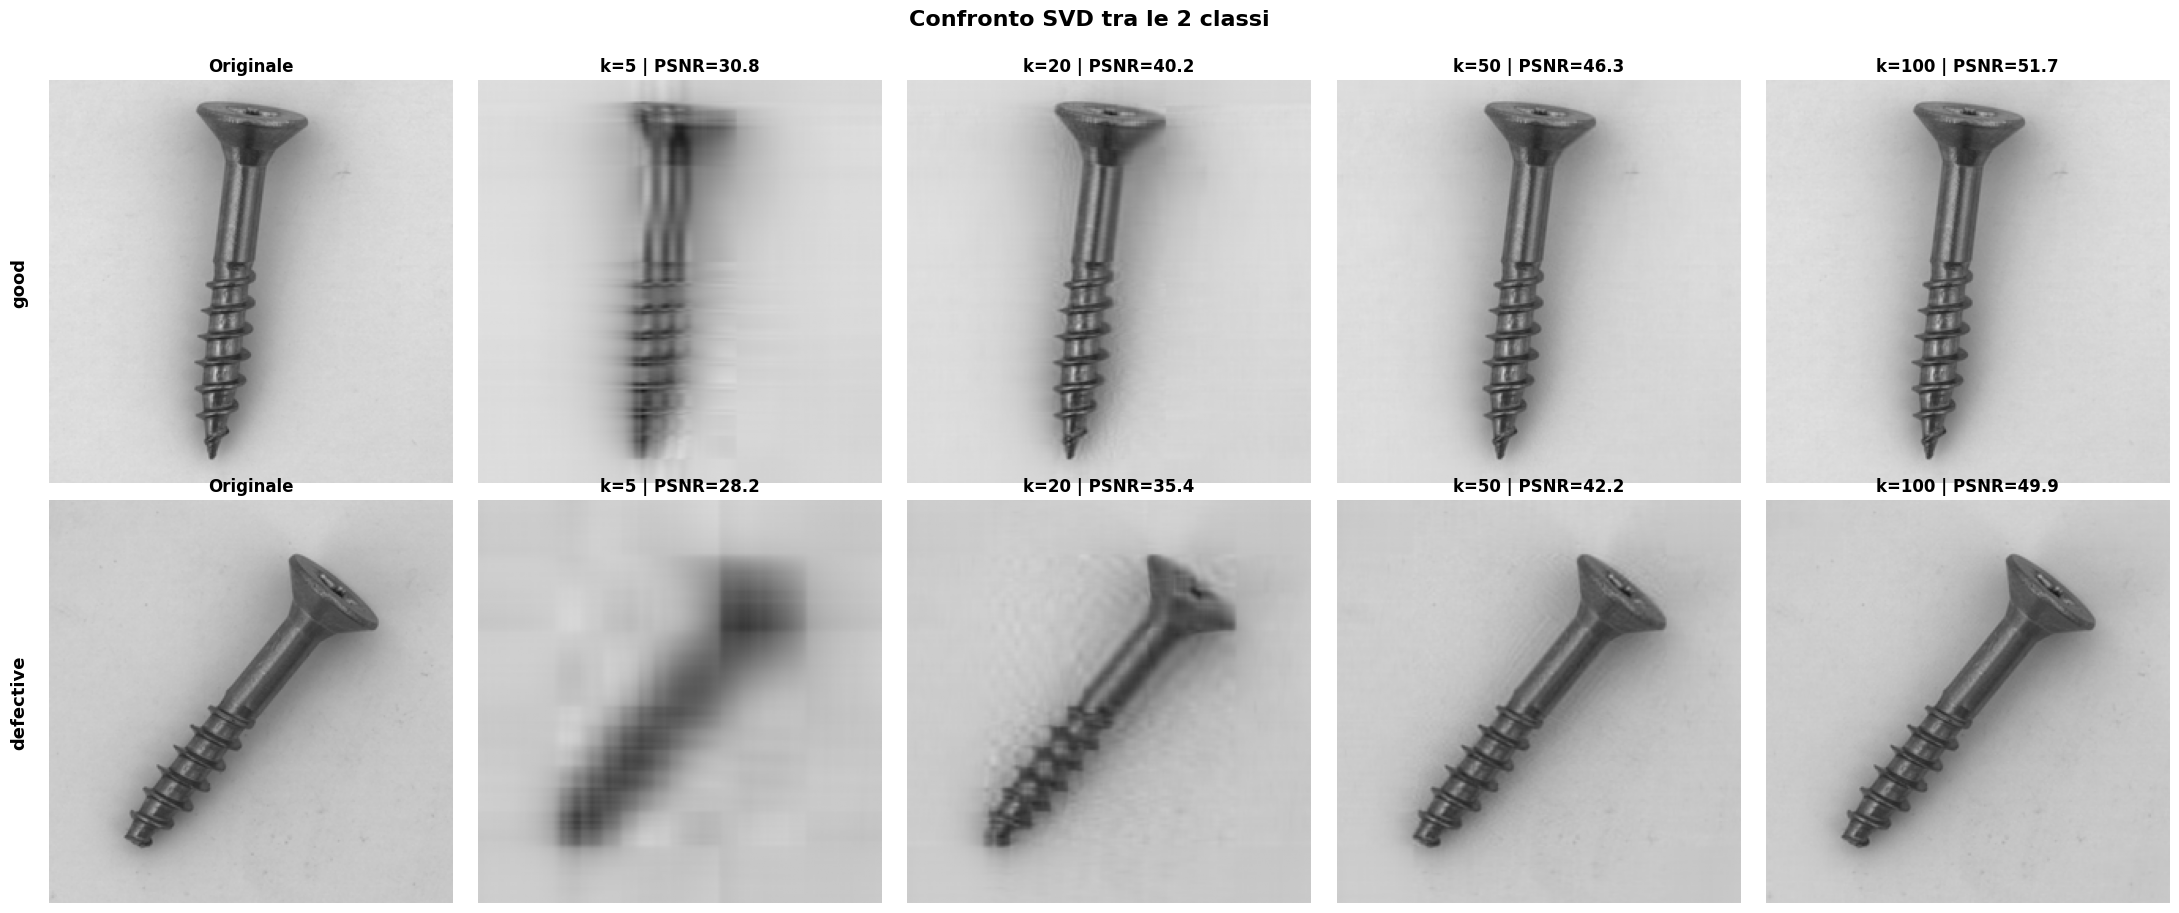

In [7]:
# === CONFRONTO SVD TRA CLASSI ===
plot_class_comparison(
    images_by_class,
    classes=MVTEC_CLASSES,
    output_dir=OUTPUT_DIR,
)

good                          :  k(90%)=  1   k(95%)=  1   k(99%)=  2  su 256 totali (valori medi)
defective                     :  k(90%)=  1   k(95%)=  1   k(99%)=  2  su 256 totali (valori medi)


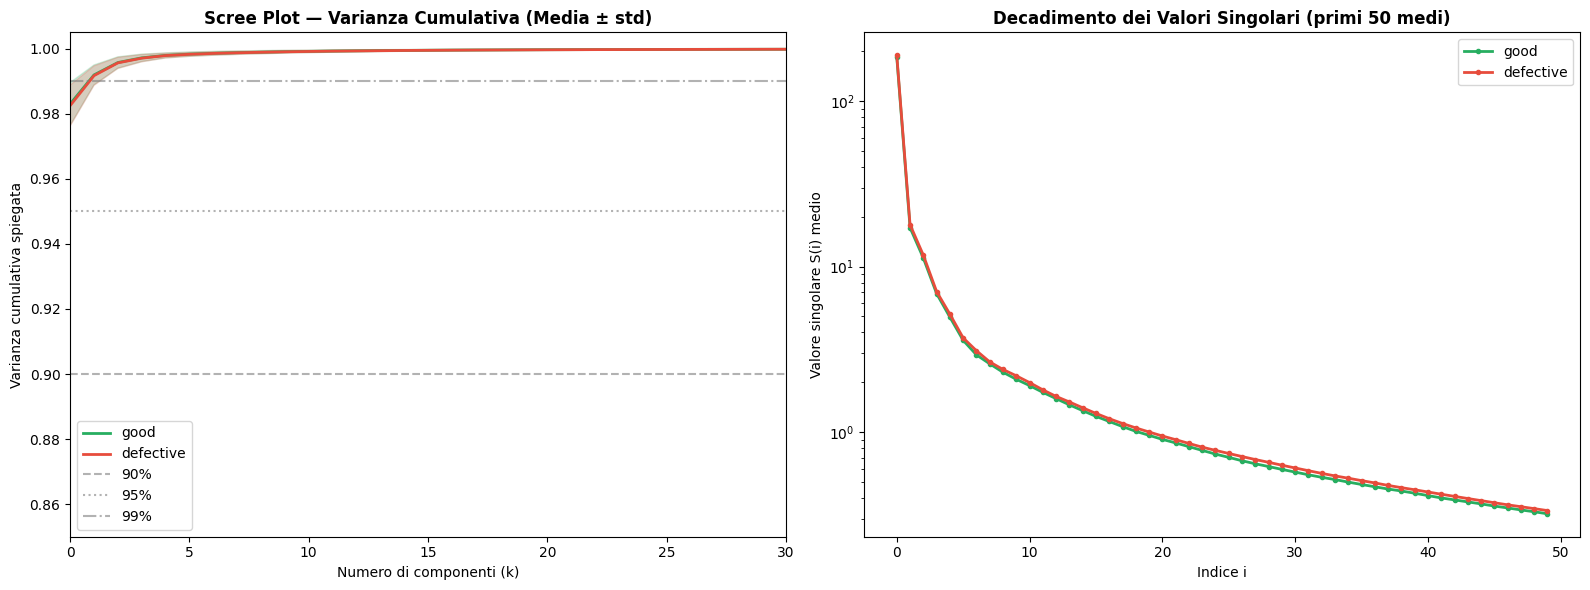

In [8]:
# === SCREE PLOT ===
# xlim/ylim zoomati: le screw sono molto compressibili, la curva sale
# ripidamente e satura vicino al 99% entro i primi 20-25 k.
plot_scree(
    images_by_class,
    classes=MVTEC_CLASSES,
    class_colors=MVTEC_CLASS_COLORS,
    output_dir=OUTPUT_DIR,
    xlim=(0, 30),
    ylim=(0.85, 1.005),
)

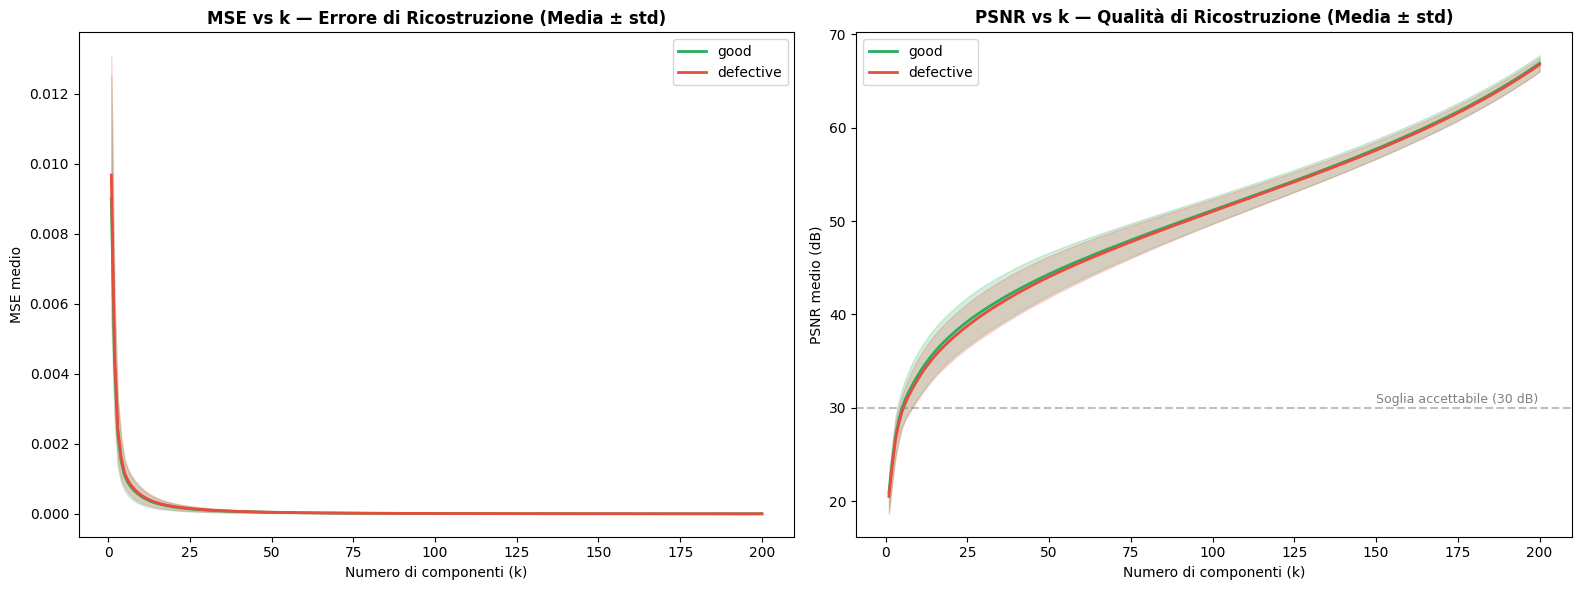

In [9]:
# === CURVE MSE e PSNR vs k ===
plot_mse_psnr(
    images_by_class,
    classes=MVTEC_CLASSES,
    class_colors=MVTEC_CLASS_COLORS,
    output_dir=OUTPUT_DIR,
)

In [10]:
# === TABELLA RIASSUNTIVA ===
print_summary_table(demo_img, class_name='good')


TABELLA RIASSUNTIVA — TRADE-OFF COMPRESSIONE vs QUALITÀ  (good)

    k |  Rapporto Compr. |   Varianza |          MSE |  PSNR (dB)
-----------------------------------------------------------------
    1 |           0.78% |    98.99% |   0.00609940 |      22.15
    5 |           3.91% |    99.86% |   0.00082753 |      30.82
   10 |           7.83% |    99.95% |   0.00027762 |      35.57
   20 |          15.66% |    99.98% |   0.00009502 |      40.22
   50 |          39.14% |   100.00% |   0.00002327 |      46.33
  100 |          78.28% |   100.00% |   0.00000678 |      51.69
  150 |         100.00% |   100.00% |   0.00000168 |      57.75
  200 |         100.00% |   100.00% |   0.00000021 |      66.74
  256 |         100.00% |   100.00% |   0.00000000 |     284.10


---
## Fase 4 — PCA sul Dataset Completo

Mentre la SVD della fase 3 opera su **una singola immagine** (decomposizione spaziale), la PCA qui opera sul **dataset intero**: ogni immagine è un punto in $\mathbb{R}^{65536}$ (256×256 pixel flatten) e la PCA trova le direzioni di massima varianza nel cloud di 238 punti.


In [11]:
# === PCA SUL DATASET ===
pca_model, X_pca = run_pca(all_images, n_components=10)

Matrice dati X: (238, 65536)  (238 campioni, 65536 features)

Varianza spiegata dalle prime 10 componenti: 81.18%


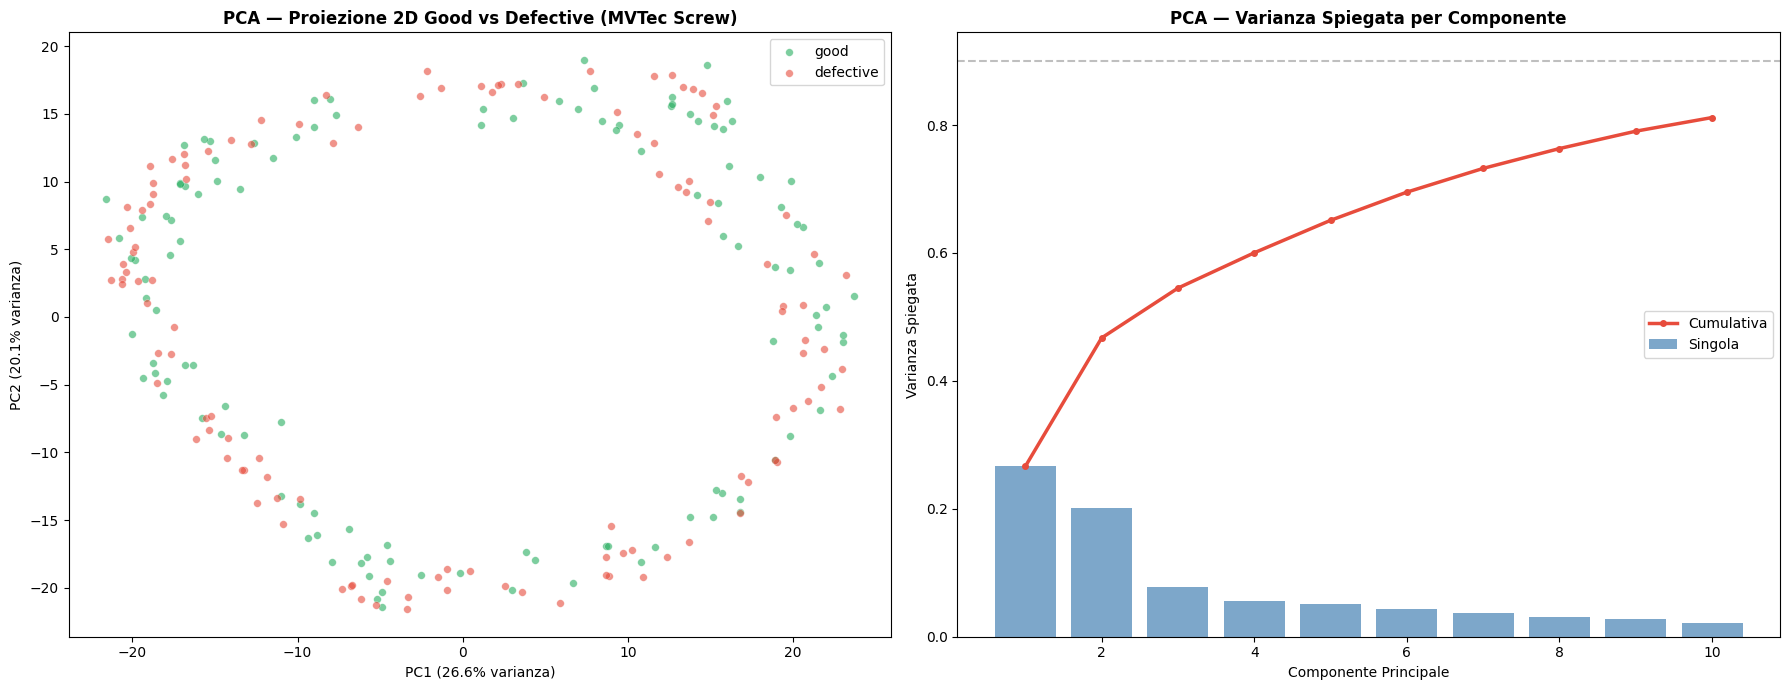

In [12]:
# === SCATTER PLOT PCA 2D ===
plot_pca_scatter(
    pca_model, X_pca, labels,
    classes=MVTEC_CLASSES,
    class_colors=MVTEC_CLASS_COLORS,
    output_dir=OUTPUT_DIR,
    title='PCA — Proiezione 2D Good vs Defective (MVTec Screw)',
)

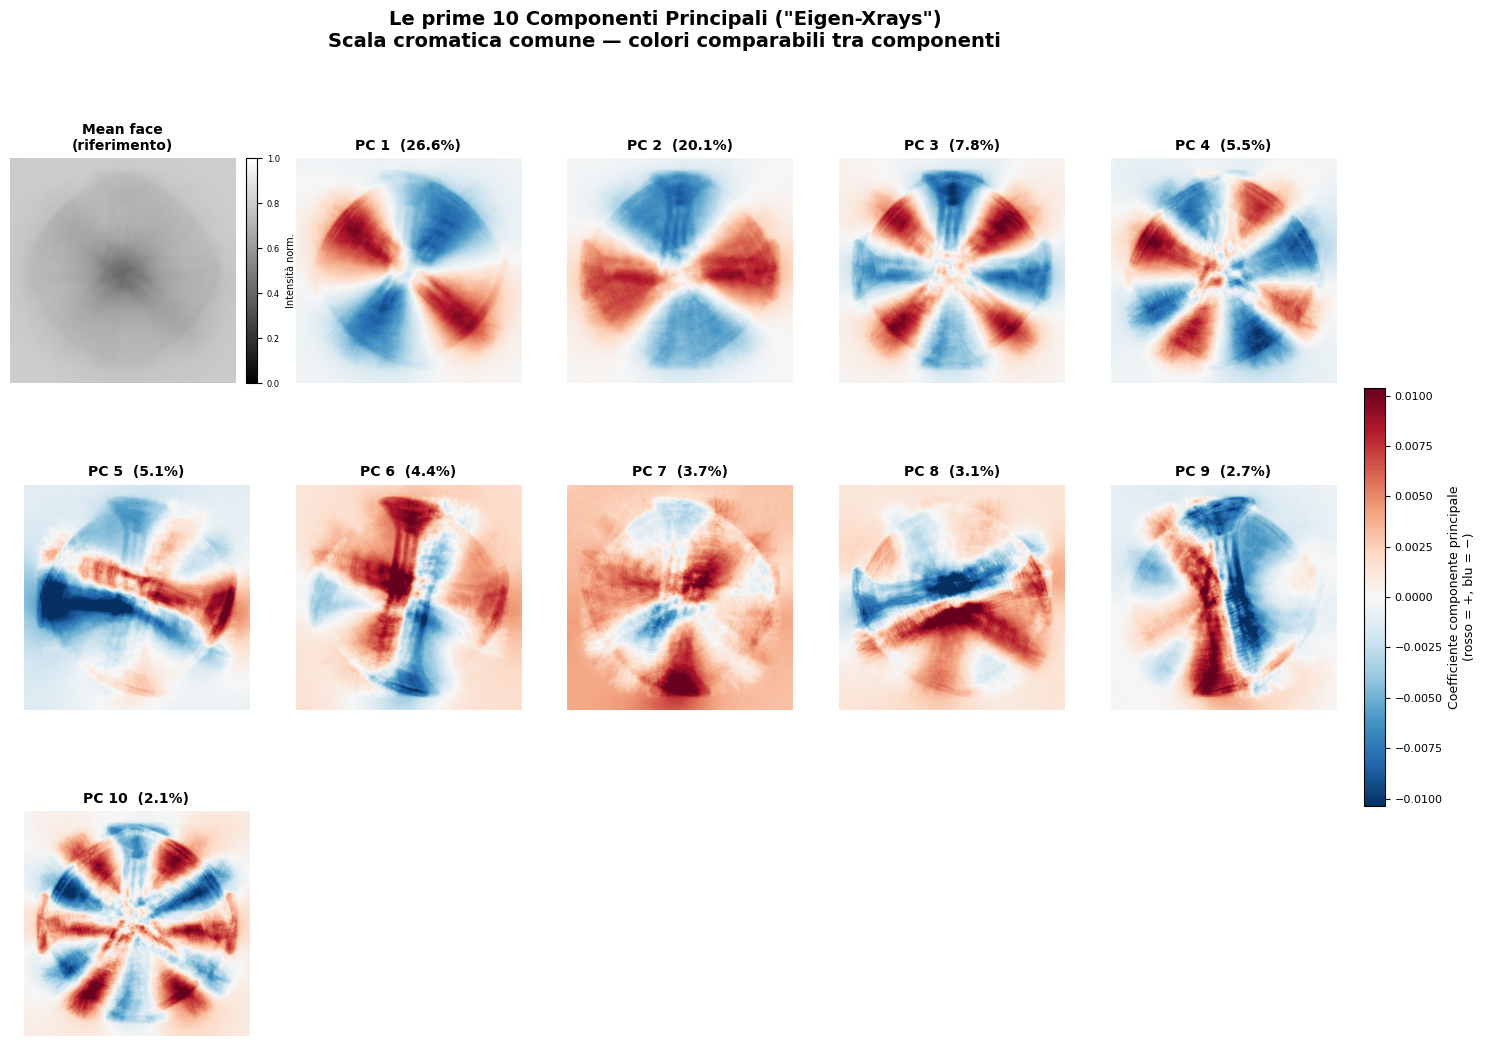

In [13]:
# === EIGEN-SCREWS (componenti principali come immagini) ===
plot_eigenfaces(
    pca_model,
    n_show=10,
    output_dir=OUTPUT_DIR,
    target_size=TARGET_SIZE,
)

---
## Fase 5 — Classificazione Binaria good vs defective

Stessa pipeline del dataset medico:
- **Baseline**: Raw Pixels (65.536 feature)
- **Strategia A — SVD**: ricostruzione a rango k, il classificatore vede i pixel ricostruiti (test: la compressione SVD è diagnosticamente lossless?)
- **Strategia B — PCA**: k coordinate principali (test: bastano k feature compatte?)

Metriche: accuracy, precision, recall, F1 (macro) e AUC-ROC. Cross-validation stratificata a 5 fold.

### Scelta critica del classificatore

Con sole 238 osservazioni e 65.536 feature (Raw Pixels) siamo in un regime fortemente sotto-campionato. Usiamo **Logistic Regression** come classificatore principale (è meno sensibile alla dimensionalità rispetto a KNN, che soffre la *curse of dimensionality*). KNN è comunque disponibile nel framework se si vuole confrontare.

### Nota sul caso binario

In classificazione binaria `LabelBinarizer` produce etichette `(N, 1)` invece di `(N, 2)`. La funzione `plot_roc_curves` gestisce automaticamente questo caso espandendo le etichette a `(N, 2)`.


In [14]:
# === PREPARAZIONE SCENARI — Logistic Regression ===
svd_cache = {}

scenarios_lr = prepare_feature_sets(
    all_images, labels,
    classifier='lr',
    svd_cache=svd_cache,
)

  [Baseline]  Raw Pixels         65536 feat  (Logistic Regression)

  -- Strategia A: SVD ricostruzione rango-k (immagine compressa) --
  [SVD k=10]  ricostr. (7.8% storage) ->  65536 feat  ricostruzione... OK
  [SVD k=25]  ricostr. (19.6% storage) ->  65536 feat  ricostruzione... OK
  [SVD k=50]  ricostr. (39.1% storage) ->  65536 feat  ricostruzione... OK

  -- Strategia B: PCA globale (pixel -> PCA(k)) --
  [PCA k=10]  65536 feat -> PCA(10) -> 10 feat  (Pipeline: Scaler->PCA(10)->Logistic Regression)
  [PCA k=25]  65536 feat -> PCA(25) -> 25 feat  (Pipeline: Scaler->PCA(25)->Logistic Regression)
  [PCA k=50]  65536 feat -> PCA(50) -> 50 feat  (Pipeline: Scaler->PCA(50)->Logistic Regression)

  Riepilogo strategie (stesso classificatore, feature diverse):
     k |    SVD: storage compr. |    PCA: dim finale | feat al classificatore
  --------------------------------------------------------------------------
    10 |                7.8% pixel |             10 dim  |           65,536 f

In [15]:
# === CLASSIFICAZIONE CON CV ===
results_lr = run_classification(scenarios_lr, labels, classifier='lr')


  RISULTATI CLASSIFICAZIONE -- Logistic Regression -- Stratified 5-Fold CV

  Scenario                   |      Accuracy      |     Precision      |       Recall       |      F1-Score     
  ------------------------------------------------------------------------------------------------
  Raw Pixels                 |  79.9%  (+/-  6.0%)  |  80.2%  (+/-  6.0%)  |  79.9%  (+/-  6.1%)  |  79.8%  (+/-  6.1%)
  SVD k=10                   |  79.5%  (+/-  4.3%)  |  79.7%  (+/-  4.4%)  |  79.5%  (+/-  4.3%)  |  79.4%  (+/-  4.3%)
  SVD k=25                   |  78.2%  (+/-  5.4%)  |  78.6%  (+/-  5.5%)  |  78.2%  (+/-  5.4%)  |  78.1%  (+/-  5.4%)
  SVD k=50                   |  79.9%  (+/-  5.8%)  |  80.3%  (+/-  5.9%)  |  79.9%  (+/-  5.8%)  |  79.8%  (+/-  5.8%)
  PCA k=10                   |  68.6%  (+/-  9.4%)  |  68.8%  (+/-  9.5%)  |  68.6%  (+/-  9.5%)  |  68.5%  (+/-  9.5%)
  PCA k=25                   |  75.3%  (+/-  7.7%)  |  75.7%  (+/-  8.0%)  |  75.3%  (+/-  7.7%)  |  75.2%  (+/

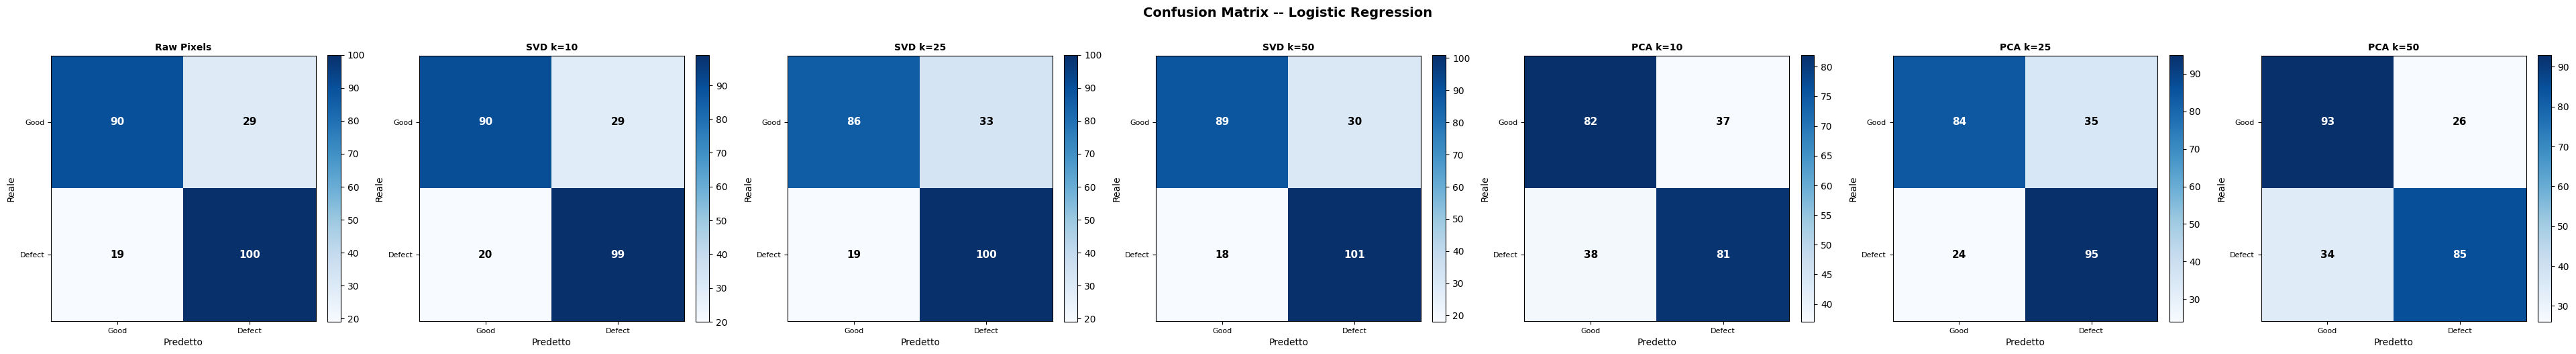

In [16]:
# === CONFUSION MATRIX ===
plot_confusion_matrix(
    scenarios_lr, labels,
    classifier='lr',
    classes=MVTEC_CLASSES,
    short_labels=MVTEC_SHORT_LABELS,
    output_dir=OUTPUT_DIR,
)

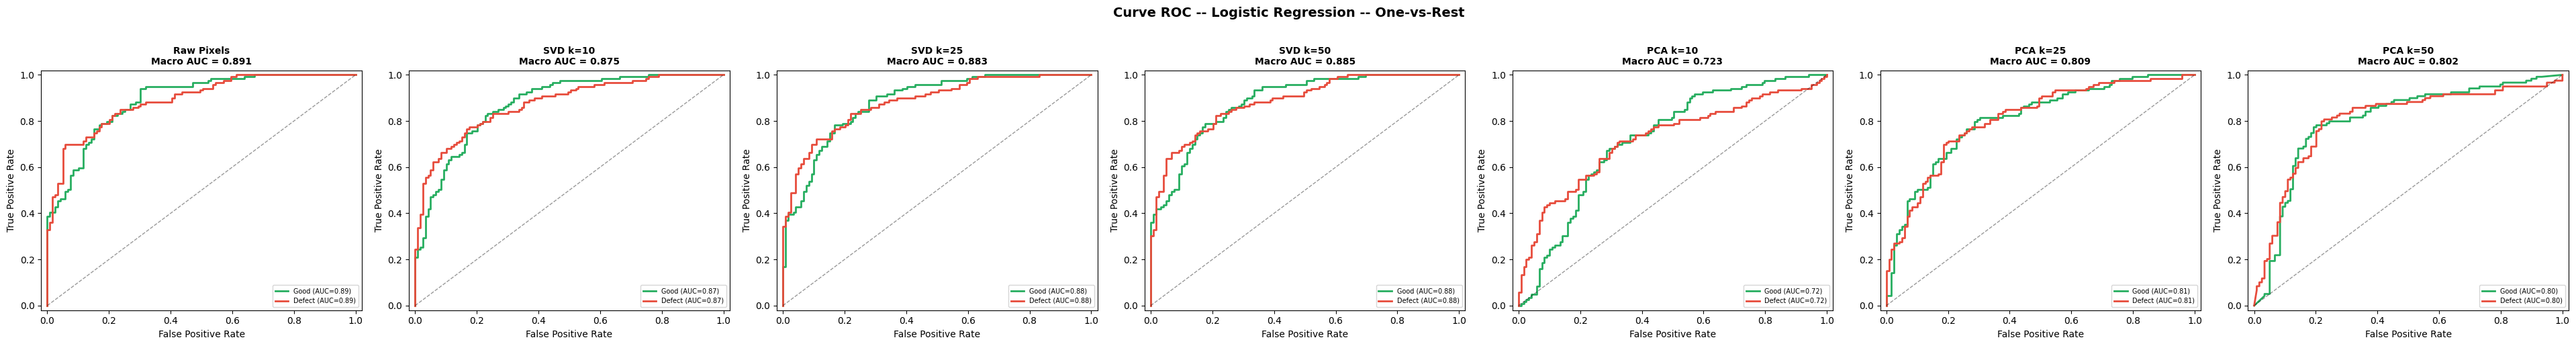

In [17]:
# === CURVE ROC (binarie) ===
plot_roc_curves(
    scenarios_lr, labels,
    classifier='lr',
    classes=MVTEC_CLASSES,
    class_colors=MVTEC_CLASS_COLORS,
    short_labels=MVTEC_SHORT_LABELS,
    output_dir=OUTPUT_DIR,
)

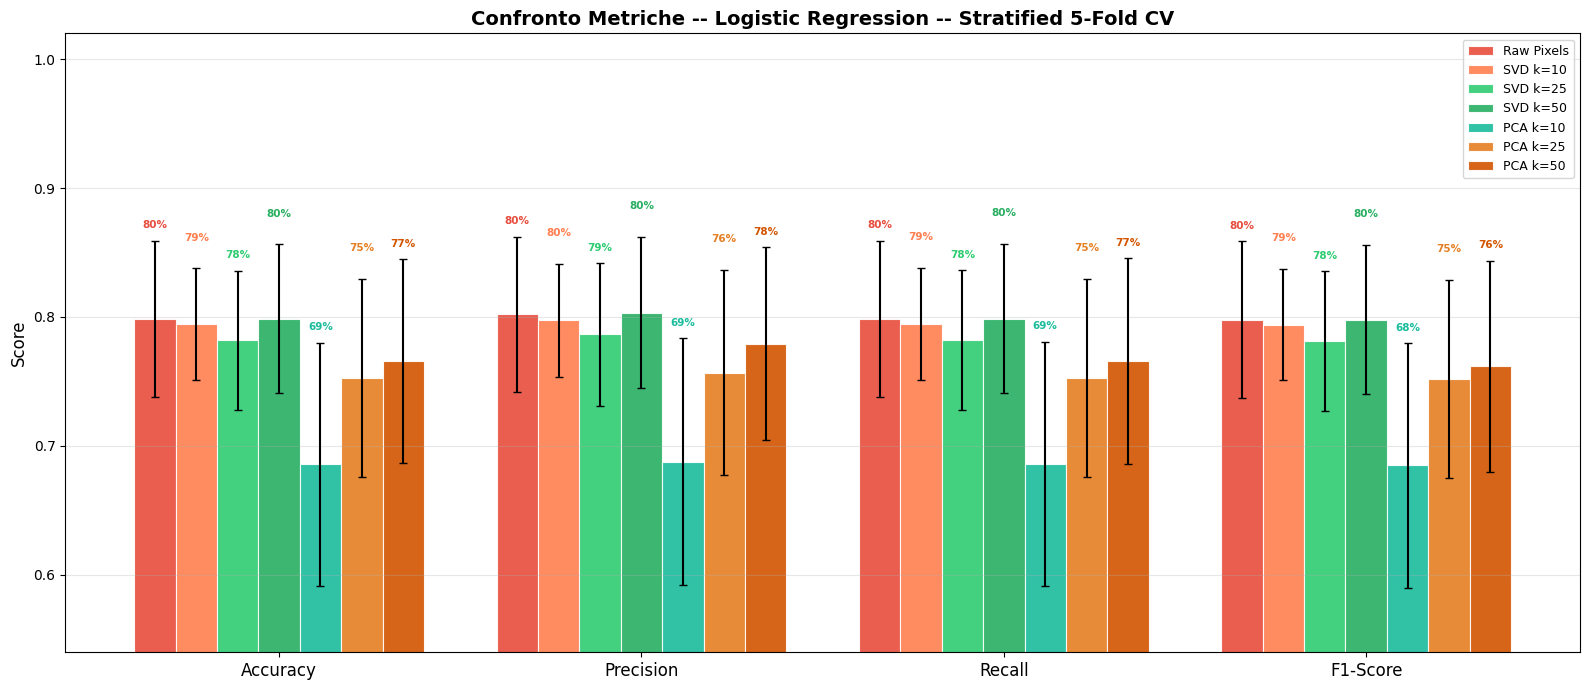

In [18]:
# === CONFRONTO METRICHE TRA SCENARI ===
plot_classification_comparison(
    results_lr,
    classifier='lr',
    output_dir=OUTPUT_DIR,
)

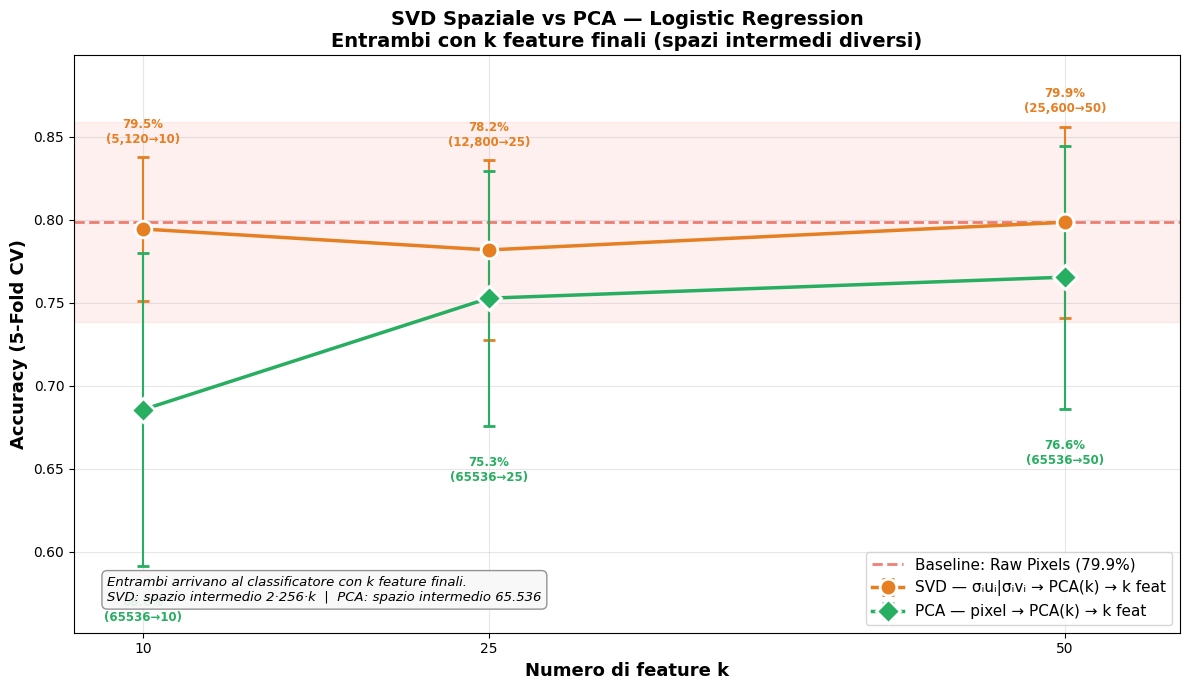

In [19]:
# === HERO CHART — SVD vs PCA ===
plot_hero_tradeoff(
    results_lr,
    classifier='lr',
    output_dir=OUTPUT_DIR,
)

---
### Versione KNN — parità col notebook medico

Il notebook medico riporta sia Logistic Regression sia K-Nearest Neighbors. Replichiamo qui la stessa pipeline con KNN per un confronto simmetrico. KNN è più sensibile alla geometria dello spazio delle feature, quindi è un test complementare: se SVD/PCA preservano la struttura locale, KNN dovrebbe comportarsi coerentemente con LR.

In [20]:
# === PREPARAZIONE SCENARI - KNN ===
# prepare_feature_sets costruisce internamente la Pipeline in base al
# classificatore: dobbiamo passare classifier='knn' per avere KNN
# come stimatore finale (diverso da quello LR di prima).
scenarios_knn = prepare_feature_sets(
    all_images, labels,
    classifier='knn',
    svd_cache=svd_cache,
)

  [Baseline]  Raw Pixels         65536 feat  (KNN (k=5))

  -- Strategia A: SVD ricostruzione rango-k (immagine compressa) --
  [SVD k=10]  ricostr. (7.8% storage) ->  65536 feat  (cache)  (KNN (k=5))
  [SVD k=25]  ricostr. (19.6% storage) ->  65536 feat  (cache)  (KNN (k=5))
  [SVD k=50]  ricostr. (39.1% storage) ->  65536 feat  (cache)  (KNN (k=5))

  -- Strategia B: PCA globale (pixel -> PCA(k)) --
  [PCA k=10]  65536 feat -> PCA(10) -> 10 feat  (Pipeline: Scaler->PCA(10)->KNN (k=5))
  [PCA k=25]  65536 feat -> PCA(25) -> 25 feat  (Pipeline: Scaler->PCA(25)->KNN (k=5))
  [PCA k=50]  65536 feat -> PCA(50) -> 50 feat  (Pipeline: Scaler->PCA(50)->KNN (k=5))

  Riepilogo strategie (stesso classificatore, feature diverse):
     k |    SVD: storage compr. |    PCA: dim finale | feat al classificatore
  --------------------------------------------------------------------------
    10 |                7.8% pixel |             10 dim  |           65,536 feat (SVD) / 10 (PCA)
    25 |        

In [21]:
# === CLASSIFICAZIONE CON KNN ===
results_knn = run_classification(scenarios_knn, labels, classifier='knn')


  RISULTATI CLASSIFICAZIONE -- KNN (k=5) -- Stratified 5-Fold CV

  Scenario                   |      Accuracy      |     Precision      |       Recall       |      F1-Score     
  ------------------------------------------------------------------------------------------------
  Raw Pixels                 |  68.5%  (+/-  6.0%)  |  69.9%  (+/-  6.1%)  |  68.5%  (+/-  6.0%)  |  67.9%  (+/-  6.2%)
  SVD k=10                   |  67.7%  (+/-  7.2%)  |  69.0%  (+/-  7.3%)  |  67.7%  (+/-  7.3%)  |  66.9%  (+/-  7.7%)
  SVD k=25                   |  68.5%  (+/-  6.0%)  |  69.9%  (+/-  6.1%)  |  68.5%  (+/-  6.0%)  |  67.9%  (+/-  6.2%)
  SVD k=50                   |  68.5%  (+/-  6.0%)  |  69.9%  (+/-  6.1%)  |  68.5%  (+/-  6.0%)  |  67.9%  (+/-  6.2%)
  PCA k=10                   |  70.6%  (+/-  6.1%)  |  71.8%  (+/-  5.6%)  |  70.6%  (+/-  6.1%)  |  70.1%  (+/-  6.5%)
  PCA k=25                   |  69.4%  (+/-  6.3%)  |  70.9%  (+/-  6.0%)  |  69.4%  (+/-  6.3%)  |  68.6%  (+/-  6.9%)
 

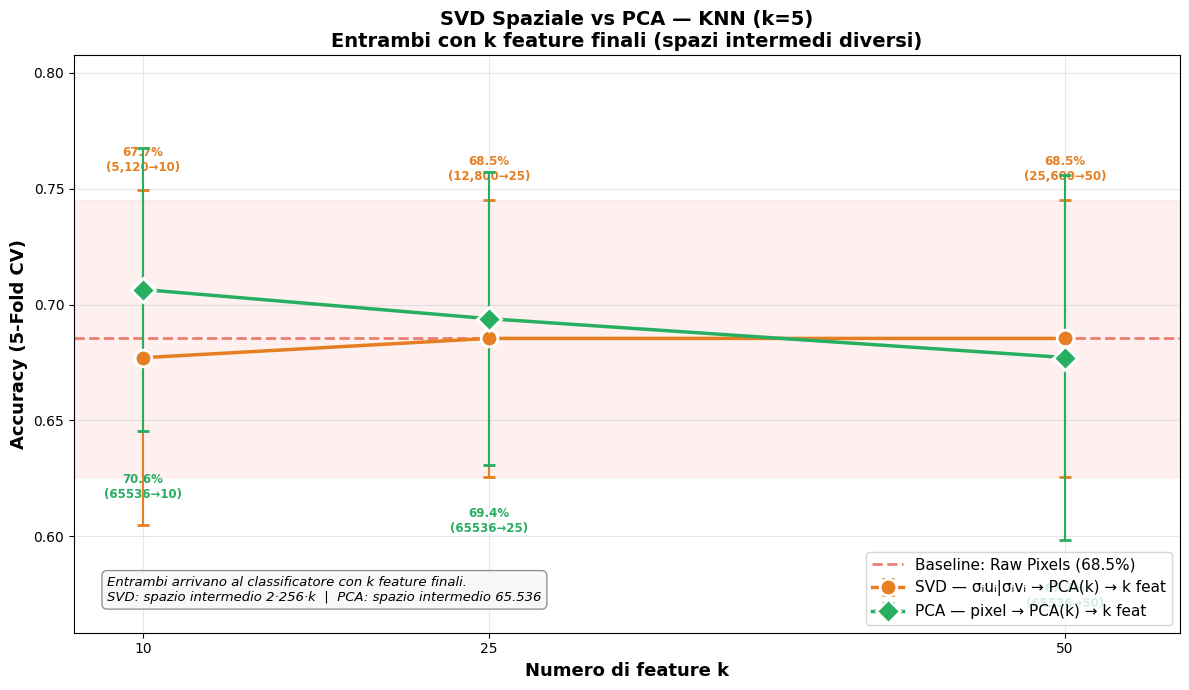

In [22]:
# === HERO CHART — SVD vs PCA (KNN) ===
plot_hero_tradeoff(
    results_knn,
    classifier='knn',
    output_dir=OUTPUT_DIR,
)

---
## Conclusioni — Confronto di SVD e PCA su un dataset differente

L'obiettivo di questa estensione non era costruire un sistema di anomaly detection, ma verificare come la stessa pipeline **SVD + PCA** si comporti quando viene applicata a un dataset diverso rispetto a quello medico, caratterizzato da oggetti molto simili tra loro ma con presenza di anomalie locali.

Da questo punto di vista, il caso MVTec è utile proprio perché permette di capire se le conclusioni ottenute sulle radiografie restano valide anche fuori dal dominio medico. La risposta è parziale: la **SVD** conferma la propria robustezza, mentre la **PCA** mostra limiti molto più evidenti.

### 1. SVD rank-k: comportamento stabile anche nel nuovo dominio

I risultati di classificazione con **Logistic Regression** restano sostanzialmente invariati rispetto alla baseline anche dopo compressione SVD:

| Scenario   | Accuracy | Δ vs Raw   |
|------------|----------|------------|
| Raw Pixels | 79.9%    | —          |
| SVD k=10   | 79.5%    | −0.4 pp    |
| SVD k=25   | 78.2%    | −1.7 pp    |
| SVD k=50   | 79.9%    | 0          |

Lo stesso pattern si osserva con **KNN**, che pur avendo accuracy assolute più basse mostra la stessa piattezza tra Raw e SVD:

| Scenario   | Accuracy (KNN) | Δ vs Raw   |
|------------|----------------|------------|
| Raw Pixels | 68.5%          | —          |
| SVD k=10   | 67.7%          | −0.8 pp    |
| SVD k=25   | 68.5%          | 0          |
| SVD k=50   | 68.5%          | 0          |

Questo conferma che, anche su immagini industriali, la SVD conserva quasi tutta l'informazione utile al task pur riducendo fortemente la rappresentazione. La conclusione principale del notebook medico sulla robustezza della **SVD** risulta confermata anche su un dataset differente, indipendentemente dal classificatore usato.

### 2. PCA globale: risultati peggiori rispetto al caso medico

La PCA mostra invece un comportamento meno stabile, che dipende in modo netto dal classificatore:

| Scenario   | Accuracy LR | Δ vs Raw LR | Accuracy KNN | Δ vs Raw KNN |
|------------|-------------|-------------|--------------|--------------|
| PCA k=10   | 68.6%       | −11.3 pp    | 70.6%        | +2.1 pp      |
| PCA k=25   | 74.9%       | −5.0 pp     | 69.4%        | +0.9 pp      |
| PCA k=50   | 75.7%       | −4.2 pp     | 66.9%        | −1.6 pp      |

Con LR la PCA è sempre sotto la baseline e migliora solo al crescere di k. Con KNN accade l'opposto: PCA k=10 è il miglior scenario in assoluto per quel classificatore, ma poi la performance si degrada all'aumentare di k (tipico effetto della *curse of dimensionality* per KNN). Questa discrepanza è un segnale forte: PCA non trasferisce automaticamente la stessa utilità osservata nel caso medico, e l'efficacia dipende dall'interazione tra geometria dello spazio ridotto e classificatore scelto.

### 3. Interpretazione del risultato

La differenza tra SVD e PCA in questo caso è un esempio chiaro della distinzione tra **fedeltà ricostruttiva** e **separabilità**. La PCA spiega una frazione molto alta della varianza con pochissime componenti — addirittura il primo valore singolare medio di ciascuna immagine copre oltre il 97% della varianza — ma questa varianza dominante non coincide necessariamente con il segnale utile al task good-vs-defective. Gran parte della varianza catturata è legata a differenze di posa, orientamento e struttura globale della vite, mentre il difetto è un segnale locale che resta nelle componenti di ordine più alto.

La SVD per immagine, invece, resta più stabile come strumento di compressione perché lavora sul singolo campione e non dipende dalla geometria globale del cloud di dati come accade per la PCA dataset-level. Questo spiega perché Raw Pixels e SVD rank-k danno risultati quasi identici: la ricostruzione SVD è un buon surrogato dell'immagine originale per tutti i k testati.

### 4. Confronto con dataset medico

L'esperimento risponde direttamente alla richiesta di applicare la pipeline a un **dataset differente con anomalie** per verificare se le conclusioni precedenti si confermano oppure no:

- si conferma la robustezza della **SVD** come tecnica di rappresentazione e compressione, sia con LR sia con KNN;
- non si conferma in modo altrettanto forte la bontà della **PCA** come rappresentazione compatta per la classificazione — la sua utilità è sensibile sia al dataset sia al classificatore scelto.

Il caso industriale non replica semplicemente il risultato del notebook medico, ma lo raffina: mostra che alcune conclusioni sono robuste, mentre altre sono sensibili al tipo di dataset e al contesto sperimentale.

